In [73]:
# define which training and validation test sets we are using (M vs F vs M+F)
training_sex = 'F'
# training_sex = 'M'
# training_sex = 'MF'

validation_sex = 'F'
# validation_sex = 'M'

# segment = 'PCT'
segment = 'mTAL'

Loaded features: (4094, 4) Loaded targets: (4094, 4)
Train: torch.Size([3275, 4]) torch.Size([3275, 4]) Val: torch.Size([819, 4]) torch.Size([819, 4])
Epoch 0001 | Train MSE: 0.968626 | Val MSE: 0.987256 | mean_grad: 1.579e-02, max_grad: 4.052e-02
Epoch 0050 | Train MSE: 0.062708 | Val MSE: 0.029138 | mean_grad: 8.062e-03, max_grad: 1.260e-02
Epoch 0100 | Train MSE: 0.045182 | Val MSE: 0.018241 | mean_grad: 1.151e-02, max_grad: 1.950e-02
Epoch 0150 | Train MSE: 0.033114 | Val MSE: 0.012108 | mean_grad: 6.775e-03, max_grad: 9.629e-03
Epoch 0200 | Train MSE: 0.026683 | Val MSE: 0.010404 | mean_grad: 8.843e-03, max_grad: 1.437e-02
Early stopping at epoch 231. Best epoch 206, val MSE 0.010036

Per-output RMSE (original units): [ 0.82054347  1.6657436  25.079714   18.187277  ]
Overall RMSE (original units): 15.517874


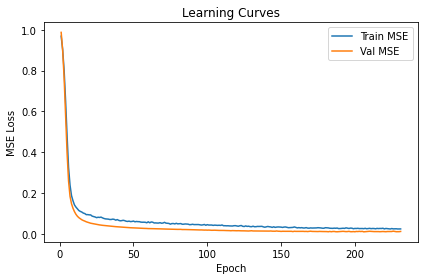

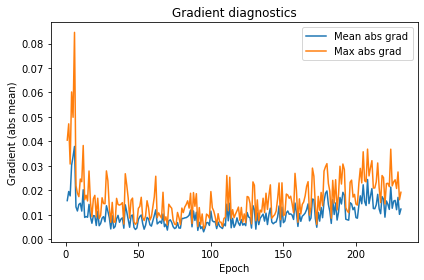

All outputs saved to folder: output_files


In [74]:
# train_regression.py
import os, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch, torch.nn as nn, torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from csv import writer

# -------------------------
# User-editable paths
# -------------------------
FEATURES_CSV = 'measure_' + segment + '_' + training_sex + '.csv'
TARGETS_CSV = 'params_' + segment + '_' + training_sex + '.csv'
# TARGETS_CSV  = "targets_mTAL_basoPK_M.csv"    # ~5,000 x 5 expected
OUTDIR = "output_files"         # directory to save model, scalers, plots
os.makedirs(OUTDIR, exist_ok=True)

# -------------------------
# Load data
# -------------------------
X_df = pd.read_csv(FEATURES_CSV)
y_df = pd.read_csv(TARGETS_CSV)
print("Loaded features:", X_df.shape, "Loaded targets:", y_df.shape)

if X_df.shape[0] != y_df.shape[0]:
    raise ValueError("Number of rows in features and targets must match")

if X_df.shape[1] != 6 or y_df.shape[1] != 5:
    print("Warning: expected shapes (N,6) and (N,5). Got:", X_df.shape, y_df.shape)

# -------------------------
# Normalize (z-score) inputs and outputs
# -------------------------
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X = scaler_X.fit_transform(X_df.values.astype(np.float32))
y = scaler_y.fit_transform(y_df.values.astype(np.float32))

# convert to torch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# -------------------------
# Train/validation split
# -------------------------
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)
print("Train:", X_train.shape, y_train.shape, "Val:", X_val.shape, y_val.shape)

# -------------------------
# Model definition
# Dense(64,R) -> Dense(64,R) -> Dense(5,linear)
# -------------------------
class MyNet(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, output_dim=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.net(x)

# model = MyNet(input_dim=6, hidden_dim=64, output_dim=5)
model = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 4)
)

# -------------------------
# Training hyperparameters
# -------------------------
criterion = nn.MSELoss()
# optimizer = optim.Adam(model.parameters(), lr=1e-3)
optimizer = optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-4)
batch_size = 32
max_epochs = 1000
patience = 25  # early stopping patience
train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train, y_train),
                                           batch_size=batch_size, shuffle=True)

# -------------------------
# Training loop: early stopping, gradients diagnostics
# -------------------------
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_epoch = -1
best_state = None
grad_stats = []

for epoch in range(1, max_epochs+1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)

    epoch_train_loss = running_loss / X_train.shape[0]
    train_losses.append(epoch_train_loss)

    # validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val).item()
    val_losses.append(val_loss)

    # gradient diagnostics (compute grads on a single batch for reporting)
    xb_sample, yb_sample = next(iter(train_loader))
    optimizer.zero_grad()
    out_sample = model(xb_sample)
    sample_loss = criterion(out_sample, yb_sample)
    sample_loss.backward()
    abs_grads = [p.grad.detach().abs().mean().item() for p in model.parameters() if p.grad is not None]
    mean_grad = float(np.mean(abs_grads)) if abs_grads else 0.0
    max_grad = float(np.max(abs_grads)) if abs_grads else 0.0
    grad_stats.append((epoch, mean_grad, max_grad))

    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:04d} | Train MSE: {epoch_train_loss:.6f} | Val MSE: {val_loss:.6f} | mean_grad: {mean_grad:.3e}, max_grad: {max_grad:.3e}")

    # early stopping & checkpoint
    if val_loss < best_val_loss - 1e-12:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = {'model': model.state_dict(), 'optimizer': optimizer.state_dict()}
        torch.save(best_state, os.path.join(OUTDIR, "best_model_checkpoint.pth"))

    if epoch - best_epoch >= patience:
        print(f"Early stopping at epoch {epoch}. Best epoch {best_epoch}, val MSE {best_val_loss:.6f}")
        break

# restore best model
if best_state is not None:
    model.load_state_dict(best_state['model'])

# -------------------------
# Evaluate and compute per-output RMSE (in original units)
# -------------------------
model.eval()
with torch.no_grad():
    y_val_pred_scaled = model(X_val).numpy()
    y_val_true_scaled = y_val.numpy()

y_val_pred_orig = scaler_y.inverse_transform(y_val_pred_scaled)
y_val_true_orig = scaler_y.inverse_transform(y_val_true_scaled)

per_output_rmse = np.sqrt(np.mean((y_val_pred_orig - y_val_true_orig)**2, axis=0))
overall_rmse = np.sqrt(np.mean((y_val_pred_orig - y_val_true_orig)**2))

print("\nPer-output RMSE (original units):", per_output_rmse)
print("Overall RMSE (original units):", overall_rmse)

# -------------------------
# Save model and scalers
# -------------------------
torch.save(model.state_dict(), os.path.join(OUTDIR, "final_model.pth"))
with open(os.path.join(OUTDIR, "scaler_X.pkl"), "wb") as f:
    pickle.dump(scaler_X, f)
with open(os.path.join(OUTDIR, "scaler_y.pkl"), "wb") as f:
    pickle.dump(scaler_y, f)
pd.DataFrame({"output_idx": np.arange(1, len(per_output_rmse)+1), "rmse": per_output_rmse}).to_csv(os.path.join(OUTDIR, "per_output_rmse.csv"), index=False)

# -------------------------
# Plots (one plot per figure)
# -------------------------
plt.figure()
plt.plot(np.arange(1, len(train_losses)+1), train_losses, label="Train MSE")
plt.plot(np.arange(1, len(val_losses)+1), val_losses, label="Val MSE")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss"); plt.title("Learning Curves"); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "learning_curve.png"))
plt.show()

epochs_arr = [g[0] for g in grad_stats]
mean_grads = [g[1] for g in grad_stats]
max_grads = [g[2] for g in grad_stats]

plt.figure()
plt.plot(epochs_arr, mean_grads, label="Mean abs grad")
plt.plot(epochs_arr, max_grads, label="Max abs grad")
plt.xlabel("Epoch"); plt.ylabel("Gradient (abs mean)"); plt.title("Gradient diagnostics"); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "grad_diagnostics.png"))
plt.show()

print(f"All outputs saved to folder: {OUTDIR}")

TRAINLOSS_CSV = 'mse_train_loss_' + segment + '_' + training_sex + '.dat'
TESTLOSS_CSV = 'mse_test_loss_' + segment + '_' + training_sex + '.dat'

with open(os.path.join(OUTDIR, TRAINLOSS_CSV), 'w') as f_object:
    for item in train_losses:
        f_object.write(f"{item}\n")
with open(os.path.join(OUTDIR, TESTLOSS_CSV), 'w') as f_object:
    for item in val_losses:
        f_object.write(f"{item}\n")

Test MSE (raw, fractional): 119.878586 0.00016418706
Per-output RMSE: [ 0.5644508  1.1182005 17.612755  12.9513035]
Normalized per-output RMSE: [0.02151818 0.00429624 0.01055013 0.05076357] 0.021782031


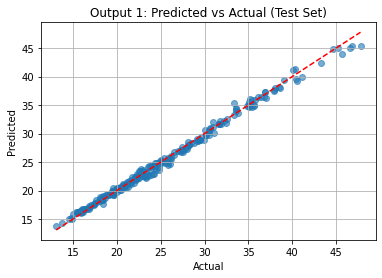

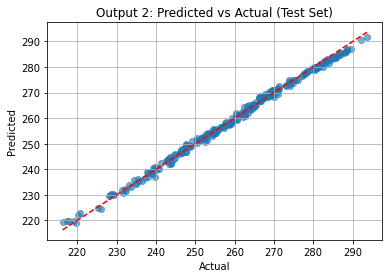

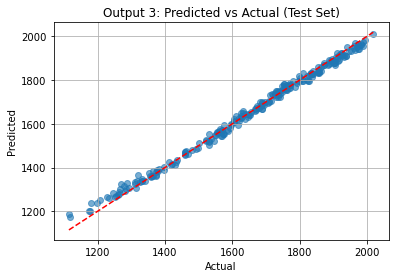

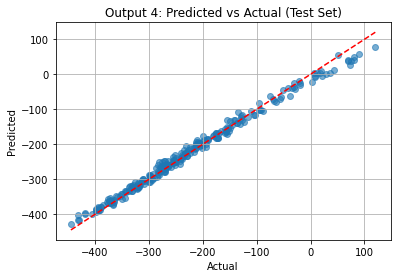

In [72]:
import pandas as pd
import torch
import numpy as np
from sklearn.metrics import mean_squared_error

# -------------------------------
# 1. Load unseen test data
# -------------------------------
FEATURES2_CSV = 'measure2_' + segment + '_' + validation_sex + '.csv'
TARGETS2_CSV = 'params2_' + segment + '_' + validation_sex + '.csv'

X_test_df = pd.read_csv(FEATURES2_CSV)
y_test_df = pd.read_csv(TARGETS2_CSV)
# X_test_df = pd.read_csv("features2_mTAL_basoPK_M.csv")
# y_test_df = pd.read_csv("targets2_mTAL_basoPK_M.csv")

# Convert to numpy
X_test = X_test_df.values.astype(np.float32)
y_test = y_test_df.values.astype(np.float32)

# -------------------------------
# 2. Apply SAME scalers used in training
# -------------------------------
# Assuming you saved the scalers as scaler_X and scaler_y
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

# Convert to torch tensors
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

# -------------------------------
# 3. Run the model in eval mode
# -------------------------------
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_tensor).numpy()

# -------------------------------
# 4. Inverse-transform predictions
# -------------------------------
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# -------------------------------
# 5. Compute metrics
# -------------------------------
# Mean squared error (physical units)
mse_test = mean_squared_error(y_test, y_pred)
frac_mse = mse_test / np.mean(y_test**2)

# Per-output RMSE
rmse_outputs = np.sqrt(np.mean((y_test - y_pred)**2, axis=0))
norm_rmse = rmse_outputs / np.sqrt(np.mean(y_test**2, axis=0))

print("Test MSE (raw, fractional):", mse_test, frac_mse)
print("Per-output RMSE:", rmse_outputs)
print("Normalized per-output RMSE:", norm_rmse, np.mean(norm_rmse))

# -------------------------------
# 6. Optional: Plot predicted vs actual
# -------------------------------
import matplotlib.pyplot as plt

n_outputs = y_test.shape[1]
for i in range(n_outputs):
    plt.figure()
    plt.scatter(y_test[:, i], y_pred[:, i], alpha=0.6)
    plt.plot([y_test[:, i].min(), y_test[:, i].max()],
             [y_test[:, i].min(), y_test[:, i].max()],
             'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Output {i+1}: Predicted vs Actual (Test Set)")
    plt.grid(True)
    plt.show()

VAL_PREDICT_CSV = 'val_predict_' + segment + '_' + training_sex + '_' + validation_sex + '.dat'
VAL_TRUTH_CSV = 'val_truth_' + segment + '_' + training_sex + '_' + validation_sex + '.dat'

# with open(os.path.join(OUTDIR, VAL_PREDICT_CSV), 'w') as f_object:
#     for item in y_pred[:,0]:
#         f_object.write(f"{item}\n")

np.savetxt(os.path.join(OUTDIR, VAL_PREDICT_CSV), y_pred, delimiter=' ', fmt='%s')
np.savetxt(os.path.join(OUTDIR, VAL_TRUTH_CSV), y_test, delimiter=' ', fmt='%s')
        
# with open(os.path.join(OUTDIR, VAL_TRUTH_CSV), 'w') as f_object:
#     for item in y_test[:,0]:
#         f_object.write(f"{item}\n")

In [66]:
print(segment)

mTAL
